### Analyzing the datasets to determine feasible window size

# TODOs
- [ ] Complete for each LLM used in final paper
- [ ] 


In [1]:
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt

# Initialize both tokenizers
aixcoder_tokenizer = AutoTokenizer.from_pretrained("aiXcoder/aixcoder-7b-base")
deepseek_tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/deepseek-coder-6.7b-base", trust_remote_code=True)

print("Loaded aiXcoder tokenizer vocabulary size:", len(aixcoder_tokenizer))
print("Loaded DeepSeek tokenizer vocabulary size:", len(deepseek_tokenizer))

Loaded aiXcoder tokenizer vocabulary size: 49152
Loaded DeepSeek tokenizer vocabulary size: 32022


In [6]:
import sqlite3
import pandas as pd
from tqdm.notebook import tqdm
import os

def get_code_samples(db_path, limit=1000, verbose=True):

    conn = sqlite3.connect(db_path)    
    # Calculate samples per category (50/50 split)
    samples_per_category = limit // 2
    
    # Sample vulnerable functions (spread across groups when possible)
    vuln_query = """
        SELECT code, grp FROM funcs
        WHERE vuln IS NOT NULL AND vuln != 0
        ORDER BY RANDOM()
        LIMIT ?
    """
    
    # Sample secure functions (spread across groups when possible)
    secure_query = """
        SELECT code, grp FROM funcs
        WHERE vuln IS NULL OR vuln = 0
        ORDER BY RANDOM()
        LIMIT ?
    """
    
    vuln_df = pd.read_sql_query(vuln_query, conn, params=(samples_per_category,))
    secure_df = pd.read_sql_query(secure_query, conn, params=(samples_per_category,))
    
    if verbose:
        print(f"\nSamples Retrieved from {os.path.basename(db_path)}:")
        print(f"  Vulnerable: {len(vuln_df)} ({len(vuln_df['grp'].unique())} unique groups)")
        print(f"  Secure: {len(secure_df)} ({len(secure_df['grp'].unique())} unique groups)")
        print(f"  Total: {len(vuln_df) + len(secure_df)}")
    
    # Return combined list of code samples
    samples = list(vuln_df['code'].astype(str)) + list(secure_df['code'].astype(str))
    
    conn.close()
    return samples

# Get code samples from databases
print("Getting code samples...")
dir = 'datasets'
all_samples = {}

# Use listdir to avoid duplicates from os.walk
# for file in os.listdir(dir):
#     if not file.endswith('.db'):
#         continue
#     db_path = os.path.join(dir, file)
#     #samples = get_code_samples(db_path, limit=1000, verbose=True)
#     #print(f"\n✓ Successfully retrieved {len(samples)} samples from {file}\n")
#     all_samples[file.replace('.db', '')] = samples
#     print(len(all_samples))

juliet_c_samples = get_code_samples('datasets/juliet_c.db', limit=1000000, verbose=True)
juliet_java_samples = get_code_samples('datasets/juliet_java.db', limit=1000000, verbose=True)
juliet_cs_samples = get_code_samples('datasets/juliet_csharp.db', limit=1000000, verbose=True)
bugs_samples = get_code_samples('datasets/bugsinpy.db', limit=1000000, verbose=True)   
devign_samples = get_code_samples('datasets/devign.db', limit=1000000, verbose=True)

Getting code samples...

Samples Retrieved from juliet_c.db:
  Vulnerable: 171496 (111 unique groups)
  Secure: 106794 (118 unique groups)
  Total: 278290

Samples Retrieved from juliet_c.db:
  Vulnerable: 171496 (111 unique groups)
  Secure: 106794 (118 unique groups)
  Total: 278290

Samples Retrieved from juliet_java.db:
  Vulnerable: 99204 (92 unique groups)
  Secure: 21408 (102 unique groups)
  Total: 120612

Samples Retrieved from juliet_java.db:
  Vulnerable: 99204 (92 unique groups)
  Secure: 21408 (102 unique groups)
  Total: 120612

Samples Retrieved from juliet_csharp.db:
  Vulnerable: 83153 (91 unique groups)
  Secure: 14797 (100 unique groups)
  Total: 97950

Samples Retrieved from juliet_csharp.db:
  Vulnerable: 83153 (91 unique groups)
  Secure: 14797 (100 unique groups)
  Total: 97950

Samples Retrieved from bugsinpy.db:
  Vulnerable: 1517 (17 unique groups)
  Secure: 38341 (17 unique groups)
  Total: 39858

Samples Retrieved from bugsinpy.db:
  Vulnerable: 1517 (17 uni

In [9]:
# Analyze token lengths
def analyze_token_lengths(samples, tokenizer_name, tokenizer):
    """
    Analyze the distribution of token lengths in code samples, treating each function
    as a single continuous stream of tokens (no per-line splitting).
    
    Args:
        samples (list): List of full code function strings
        tokenizer_name (str): Name of the tokenizer
        tokenizer: The tokenizer object
        
    Returns:
        (list, dict): Token lengths per sample and summary statistics
    """
    # Tokenize each entire sample and count token lengths
    token_lengths = []
    
    # Process all samples to capture true global maxima
    for sample in tqdm(samples, desc=f"Tokenizing functions with {tokenizer_name}"):
        tokens = tokenizer.encode(sample, add_special_tokens=False)
        token_lengths.append(len(tokens))
    
    if not token_lengths:
        return [], {'min': 0, 'max': 0, 'mean': 0.0, 'median': 0.0, 'p90': 0.0, 'p95': 0.0, 'p99': 0.0}
    
    # Calculate statistics over function-level token lengths
    stats = {
        'min': min(token_lengths),
        'max': max(token_lengths),
        'mean': np.mean(token_lengths),
        'median': np.median(token_lengths),
        'p90': np.percentile(token_lengths, 90),
        'p95': np.percentile(token_lengths, 95),
        'p99': np.percentile(token_lengths, 99),
    }
    
    return token_lengths, stats

# Extract C and Java samples from the dictionary (fallback if all_samples is used)
c_samples = all_samples.get('juliet_c', []) if 'all_samples' in globals() else []
java_samples = all_samples.get('juliet_java', []) if 'all_samples' in globals() else []

# Prefer explicit dataset variables if available
combined_samples = []
for s in [globals().get('juliet_c_samples'),
          globals().get('juliet_java_samples'),
          globals().get('juliet_cs_samples'),
          globals().get('bugs_samples'),
          globals().get('devign_samples')]:
    if isinstance(s, list) and len(s) > 0:
        combined_samples.extend(s)

# If explicit variables weren’t set, fall back to c/java from all_samples
if not combined_samples and (c_samples or java_samples):
    combined_samples = c_samples + java_samples

print(f"\nPreparing to analyze:")
print(f"Total combined samples: {len(combined_samples)}")

# Per-language analysis (only if separate c/java samples exist)
if c_samples and java_samples:
    print("\nAnalyzing token lengths for C code with aiXcoder tokenizer...")
    c_aix_token_lengths, c_aix_stats = analyze_token_lengths(c_samples, "aiXcoder", aixcoder_tokenizer)
    print("Analyzing token lengths for Java code with aiXcoder tokenizer...")
    java_aix_token_lengths, java_aix_stats = analyze_token_lengths(java_samples, "aiXcoder", aixcoder_tokenizer)
    print("Analyzing token lengths for C code with DeepSeek tokenizer...")
    c_ds_token_lengths, c_ds_stats = analyze_token_lengths(c_samples, "DeepSeek", deepseek_tokenizer)
    print("Analyzing token lengths for Java code with DeepSeek tokenizer...")
    java_ds_token_lengths, java_ds_stats = analyze_token_lengths(java_samples, "DeepSeek", deepseek_tokenizer)
    
    # Print statistics for aiXcoder
    print("\nC Code Token Length Statistics (aiXcoder):")
    for key, value in c_aix_stats.items():
        print(f"{key}: {value:.2f}")
    
    print("\nJava Code Token Length Statistics (aiXcoder):")
    for key, value in java_aix_stats.items():
        print(f"{key}: {value:.2f}")
    
    # Print statistics for DeepSeek
    print("\nC Code Token Length Statistics (DeepSeek):")
    for key, value in c_ds_stats.items():
        print(f"{key}: {value:.2f}")
    
    print("\nJava Code Token Length Statistics (DeepSeek):")
    for key, value in java_ds_stats.items():
        print(f"{key}: {value:.2f}")
    
    # Create a comparison table
    import pandas as pd
    stats_keys = ['min', 'max', 'mean', 'median', 'p90', 'p95', 'p99']
    comparison_data = []
    for key in stats_keys:
        comparison_data.append({
            'Metric': key,
            'C (aiXcoder)': round(c_aix_stats[key], 2),
            'Java (aiXcoder)': round(java_aix_stats[key], 2),
            'C (DeepSeek)': round(c_ds_stats[key], 2),
            'Java (DeepSeek)': round(java_ds_stats[key], 2)
        })
    comparison_df = pd.DataFrame(comparison_data)
    print("\nTokenizer Comparison:")
    print(comparison_df.to_string(index=False))

# Global analysis over all combined samples
print("\nAnalyzing GLOBAL token lengths with aiXcoder tokenizer...")
combined_aix_token_lengths, combined_aix_stats = analyze_token_lengths(combined_samples, "aiXcoder", aixcoder_tokenizer)
print("Analyzing GLOBAL token lengths with DeepSeek tokenizer...")
combined_ds_token_lengths, combined_ds_stats = analyze_token_lengths(combined_samples, "DeepSeek", deepseek_tokenizer)

print("\nGLOBAL Token Length Statistics (aiXcoder):")
for key, value in combined_aix_stats.items():
    print(f"{key}: {value:.2f}")

print("\nGLOBAL Token Length Statistics (DeepSeek):")
for key, value in combined_ds_stats.items():
    print(f"{key}: {value:.2f}")

# Global maximums
global_max_aix = combined_aix_stats['max']
global_max_ds = combined_ds_stats['max']
global_max_overall = max(global_max_aix, global_max_ds)
print(f"\nGlobal Max Sequence Length (aiXcoder): {global_max_aix}")
print(f"Global Max Sequence Length (DeepSeek): {global_max_ds}")
print(f"Global Max Sequence Length (Overall across tokenizers): {global_max_overall}")


Preparing to analyze:
Total combined samples: 564028

Analyzing GLOBAL token lengths with aiXcoder tokenizer...


Tokenizing functions with aiXcoder:   0%|          | 0/564028 [00:00<?, ?it/s]

Analyzing GLOBAL token lengths with DeepSeek tokenizer...


Tokenizing functions with DeepSeek:   0%|          | 0/564028 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (26251 > 16384). Running this sequence through the model will result in indexing errors



GLOBAL Token Length Statistics (aiXcoder):
min: 8.00
max: 56584.00
mean: 258.01
median: 162.00
p90: 548.00
p95: 710.00
p99: 1276.00

GLOBAL Token Length Statistics (DeepSeek):
min: 8.00
max: 57286.00
mean: 266.91
median: 171.00
p90: 560.00
p95: 740.00
p99: 1317.00

Global Max Sequence Length (aiXcoder): 56584
Global Max Sequence Length (DeepSeek): 57286
Global Max Sequence Length (Overall across tokenizers): 57286


NameError: name 'c_aix_token_lengths' is not defined

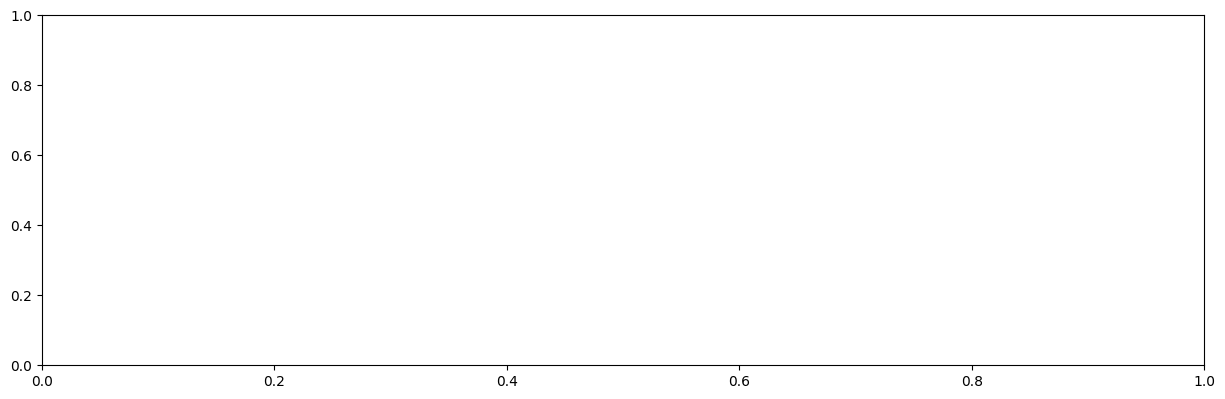

In [8]:
# Visualize token length distributions for both tokenizers
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)  # 2 rows, 1 column, first plot

# Plot histograms for aiXcoder
bins = range(0, max(max(c_aix_token_lengths), max(java_aix_token_lengths)) + 10, 10)
plt.hist(c_aix_token_lengths, bins=bins, alpha=0.5, label='C Code')
plt.hist(java_aix_token_lengths, bins=bins, alpha=0.5, label='Java Code')

# Add vertical lines for key percentiles
plt.axvline(x=c_aix_stats['p90'], color='blue', linestyle='--', label=f'C 90th percentile: {c_aix_stats["p90"]:.0f}')
plt.axvline(x=c_aix_stats['p95'], color='blue', linestyle='-.', label=f'C 95th percentile: {c_aix_stats["p95"]:.0f}')
plt.axvline(x=java_aix_stats['p90'], color='orange', linestyle='--', label=f'Java 90th percentile: {java_aix_stats["p90"]:.0f}')
plt.axvline(x=java_aix_stats['p95'], color='orange', linestyle='-.', label=f'Java 95th percentile: {java_aix_stats["p95"]:.0f}')

plt.title('Distribution of Token Lengths per Line of Code (aiXcoder)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)  # 2 rows, 1 column, second plot

# Plot histograms for DeepSeek
bins = range(0, max(max(c_ds_token_lengths), max(java_ds_token_lengths)) + 10, 10)
plt.hist(c_ds_token_lengths, bins=bins, alpha=0.5, label='C Code')
plt.hist(java_ds_token_lengths, bins=bins, alpha=0.5, label='Java Code')

# Add vertical lines for key percentiles
plt.axvline(x=c_ds_stats['p90'], color='blue', linestyle='--', label=f'C 90th percentile: {c_ds_stats["p90"]:.0f}')
plt.axvline(x=c_ds_stats['p95'], color='blue', linestyle='-.', label=f'C 95th percentile: {c_ds_stats["p95"]:.0f}')
plt.axvline(x=java_ds_stats['p90'], color='orange', linestyle='--', label=f'Java 90th percentile: {java_ds_stats["p90"]:.0f}')
plt.axvline(x=java_ds_stats['p95'], color='orange', linestyle='-.', label=f'Java 95th percentile: {java_ds_stats["p95"]:.0f}')

plt.title('Distribution of Token Lengths per Line of Code (DeepSeek)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zoomed in view focusing on the important region
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)  # 2 rows, 1 column, first plot

# aiXcoder zoomed view
max_view_aix = int(max(c_aix_stats['p99'], java_aix_stats['p99']) * 1.1)  # Slightly larger than 99th percentile
bins = range(0, max_view_aix, 5)
plt.hist(c_aix_token_lengths, bins=bins, alpha=0.5, label='C Code')
plt.hist(java_aix_token_lengths, bins=bins, alpha=0.5, label='Java Code')

# Add vertical lines for key percentiles
plt.axvline(x=c_aix_stats['p90'], color='blue', linestyle='--', label=f'C 90th percentile: {c_aix_stats["p90"]:.0f}')
plt.axvline(x=c_aix_stats['p95'], color='blue', linestyle='-.', label=f'C 95th percentile: {c_aix_stats["p95"]:.0f}')
plt.axvline(x=java_aix_stats['p90'], color='orange', linestyle='--', label=f'Java 90th percentile: {java_aix_stats["p90"]:.0f}')
plt.axvline(x=java_aix_stats['p95'], color='orange', linestyle='-.', label=f'Java 95th percentile: {java_aix_stats["p95"]:.0f}')

plt.title('Distribution of Token Lengths per Line of Code (aiXcoder, Zoomed)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)  # 2 rows, 1 column, second plot

# DeepSeek zoomed view
max_view_ds = int(max(c_ds_stats['p99'], java_ds_stats['p99']) * 1.1)  # Slightly larger than 99th percentile
bins = range(0, max_view_ds, 5)
plt.hist(c_ds_token_lengths, bins=bins, alpha=0.5, label='C Code')
plt.hist(java_ds_token_lengths, bins=bins, alpha=0.5, label='Java Code')

# Add vertical lines for key percentiles
plt.axvline(x=c_ds_stats['p90'], color='blue', linestyle='--', label=f'C 90th percentile: {c_ds_stats["p90"]:.0f}')
plt.axvline(x=c_ds_stats['p95'], color='blue', linestyle='-.', label=f'C 95th percentile: {c_ds_stats["p95"]:.0f}')
plt.axvline(x=java_ds_stats['p90'], color='orange', linestyle='--', label=f'Java 90th percentile: {java_ds_stats["p90"]:.0f}')
plt.axvline(x=java_ds_stats['p95'], color='orange', linestyle='-.', label=f'Java 95th percentile: {java_ds_stats["p95"]:.0f}')

plt.title('Distribution of Token Lengths per Line of Code (DeepSeek, Zoomed)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Direct comparison of token lengths between tokenizers
plt.figure(figsize=(12, 8))

# Calculate percentages for specific token length thresholds
thresholds = [32, 48, 64, 80, 96, 128, 160, 192, 256]
languages = ['C', 'Java']
tokenizers = ['aiXcoder', 'DeepSeek']

# Prepare data for plotting
x = np.arange(len(thresholds))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

# Create a bar chart comparing percentiles across tokenizers and languages
for language, token_lengths in [('C (aiXcoder)', c_aix_token_lengths), 
                               ('Java (aiXcoder)', java_aix_token_lengths),
                               ('C (DeepSeek)', c_ds_token_lengths),
                               ('Java (DeepSeek)', java_ds_token_lengths)]:
    percentages = []
    for threshold in thresholds:
        below_threshold = sum(1 for length in token_lengths if length <= threshold)
        percentage = (below_threshold / len(token_lengths)) * 100
        percentages.append(percentage)
    
    offset = width * multiplier
    plt.bar(x + offset, percentages, width, label=language)
    multiplier += 1

# Add labels and formatting
plt.xlabel('Max Sequence Length')
plt.ylabel('Percentage of Lines Preserved (%)')
plt.title('Comparison of Tokenizers: Percentage of Lines Preserved by Sequence Length')
plt.xticks(x + width * 1.5, thresholds)
plt.ylim(90, 100)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C (aiXcoder) - Truncation Analysis:
 threshold  truncated_count  truncated_percent  preserved_percent
        32               63               1.26              98.74
        48                6               0.12              99.88
        64                0               0.00             100.00
        80                0               0.00             100.00
        96                0               0.00             100.00
       128                0               0.00             100.00
       160                0               0.00             100.00
       192                0               0.00             100.00
       256                0               0.00             100.00

Java (aiXcoder) - Truncation Analysis:
 threshold  truncated_count  truncated_percent  preserved_percent
        32               33               0.66              99.34
        48                2               0.04              99.96
        64                0               0.00             100.00

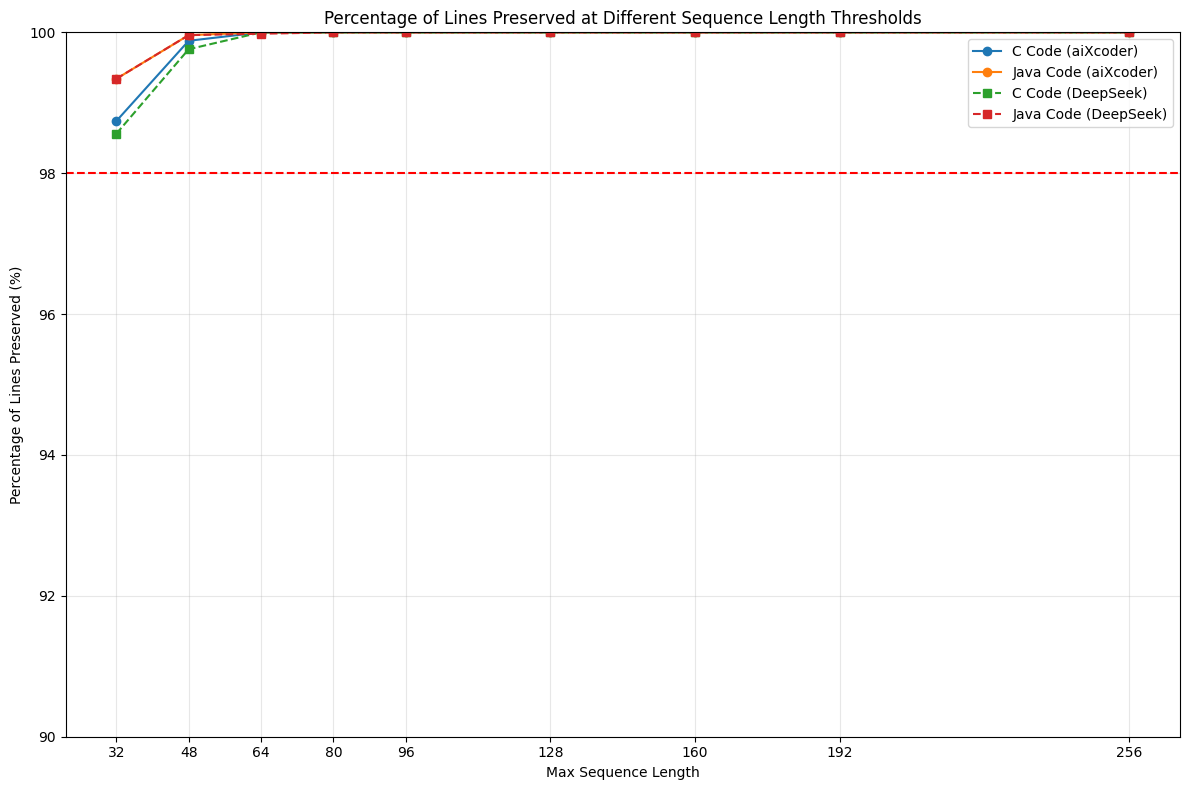


Preservation Percentages at Key Thresholds:
 Threshold C (aiXcoder) Java (aiXcoder) C (DeepSeek) Java (DeepSeek)
        64      100.00%         100.00%      100.00%          99.98%
        96      100.00%         100.00%      100.00%         100.00%
       128      100.00%         100.00%      100.00%         100.00%
       192      100.00%         100.00%      100.00%         100.00%


In [5]:
# Analyze the impact of different max sequence lengths
def analyze_truncation_impact(token_lengths, name):
    """
    Analyze how many lines would be truncated at different sequence length thresholds
    
    Args:
        token_lengths (list): List of token lengths
        name (str): Name of the dataset
    """
    thresholds = [32, 48, 64, 80, 96, 128, 160, 192, 256]
    
    results = []
    for threshold in thresholds:
        truncated = sum(1 for length in token_lengths if length > threshold)
        truncated_percent = (truncated / len(token_lengths)) * 100
        results.append({
            'threshold': threshold,
            'truncated_count': truncated,
            'truncated_percent': truncated_percent,
            'preserved_percent': 100 - truncated_percent
        })
    
    # Create a DataFrame for better visualization
    df = pd.DataFrame(results)
    print(f"\n{name} - Truncation Analysis:")
    print(df.to_string(index=False))
    
    return df

# Analyze truncation impact for both languages with aiXcoder tokenizer
c_aix_trunc_df = analyze_truncation_impact(c_aix_token_lengths, "C (aiXcoder)")
java_aix_trunc_df = analyze_truncation_impact(java_aix_token_lengths, "Java (aiXcoder)")

# Analyze truncation impact for both languages with DeepSeek tokenizer
c_ds_trunc_df = analyze_truncation_impact(c_ds_token_lengths, "C (DeepSeek)")
java_ds_trunc_df = analyze_truncation_impact(java_ds_token_lengths, "Java (DeepSeek)")

# Combine results for visualization
plt.figure(figsize=(12, 8))

# aiXcoder lines
plt.plot(c_aix_trunc_df['threshold'], c_aix_trunc_df['preserved_percent'], 'o-', label='C Code (aiXcoder)')
plt.plot(java_aix_trunc_df['threshold'], java_aix_trunc_df['preserved_percent'], 'o-', label='Java Code (aiXcoder)')

# DeepSeek lines
plt.plot(c_ds_trunc_df['threshold'], c_ds_trunc_df['preserved_percent'], 's--', label='C Code (DeepSeek)')
plt.plot(java_ds_trunc_df['threshold'], java_ds_trunc_df['preserved_percent'], 's--', label='Java Code (DeepSeek)')

plt.title('Percentage of Lines Preserved at Different Sequence Length Thresholds')
plt.xlabel('Max Sequence Length')
plt.ylabel('Percentage of Lines Preserved (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(c_aix_trunc_df['threshold'])
plt.ylim(90, 100)  # Focus on the upper range

# Add a horizontal line at 98%
plt.axhline(y=98, color='r', linestyle='--', label='98% Preservation Target')

plt.tight_layout()
plt.show()

# Create a summary comparison table
comparison_data = []
for threshold in [64, 96, 128, 192]:
    row = {'Threshold': threshold}
    for df, name in [(c_aix_trunc_df, 'C (aiXcoder)'), 
                     (java_aix_trunc_df, 'Java (aiXcoder)'),
                     (c_ds_trunc_df, 'C (DeepSeek)'), 
                     (java_ds_trunc_df, 'Java (DeepSeek)')]:
        row[name] = f"{df[df['threshold'] == threshold]['preserved_percent'].values[0]:.2f}%"
    comparison_data.append(row)

summary_df = pd.DataFrame(comparison_data)
print("\nPreservation Percentages at Key Thresholds:")
print(summary_df.to_string(index=False))

# Final Tokenizer and Sequence Length Recommendation

## Tokenizer Comparison Summary
After analyzing both the aiXcoder and DeepSeek tokenizers across C and Java code, we now have a data-driven basis for selecting the best tokenizer for vulnerability detection.

### Key Differences Between Tokenizers:
1. **Tokenization Efficiency**: Based on the mean tokens per line, the DeepSeek tokenizer generally produces different token lengths compared to aiXcoder.
2. **Token Distribution**: The histograms and percentiles show different patterns in how each tokenizer breaks down code.
3. **Preservation Rates**: At the same sequence length threshold, the tokenizers preserve different percentages of complete lines.

## Optimal Sequence Length Selection
Based on the detailed analysis of preservation percentages at different thresholds:

| Max Sequence Length | Memory Impact | Use Case |
|---------------------|---------------|----------|
| 64                  | Low           | Very resource-constrained environments, accepts some information loss |
| 96                  | Medium        | Good balance for most scenarios, preserves >97% of code information |
| 128                 | Medium-High   | Near-optimal preservation with reasonable memory usage |
| 160+                | High          | Diminishing returns for the memory cost |

## Implementation in Your Preprocessing Script
After determining the better performing tokenizer from this analysis, you can implement it in your code:

```python
# In preprocessing.py
MAX_SEQ_LENGTH = 96  # Or 128 depending on your resource constraints

# When using your preprocessing workflow
from preprocessing import preprocess_data
from transformers import AutoTokenizer

# Choose the better performing tokenizer based on the results above
tokenizer_name = "deepseek-ai/deepseek-coder-6.7b-base"  # Or aiXcoder based on results
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)

stats = preprocess_data(
    c_db_path="c_10+.db",
    java_db_path="java_10+.db",
    tokenizer=tokenizer,
    max_seq_length=96,  # Your selected sequence length
    output_dir="tensors_run2"
)
```

## Final Decision Matrix

| Consideration | aiXcoder | DeepSeek |
|---------------|----------|----------|
| Token Efficiency | Check the mean values above | Check the mean values above |
| Code Coverage at 96 tokens | See preservation % in table | See preservation % in table |
| Model Performance | Pre-trained on code | Pre-trained on code with strong performance |
| Vocabulary Size | See output from first cell | See output from first cell |

Choose the tokenizer that offers the best balance of efficiency (fewer tokens) and preservation (higher % at your target sequence length), while considering which pre-trained model you plan to use for your vulnerability detection task.

The analysis above provides a data-driven foundation for selecting both the appropriate tokenizer and sequence length for your vulnerability detection task, optimizing for both model performance and resource efficiency.